In [42]:
#Importing all the necessary libraries
import pandas as pd        # for tables
import numpy as np         # for numbers and math
import matplotlib.pyplot as plt   # for drawing graphs
import seaborn as sns      
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [2]:
#loading the dataset
df = pd.read_csv("heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [3]:
print("shape:", df.shape)

shape: (1025, 14)


In [4]:
print("column names:", df.columns.tolist())

column names: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


In [5]:
print("column data types:", df.dtypes)

column data types: age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object


In [6]:
print("Missing values:", df.isnull().sum())

Missing values: age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [7]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [8]:
# Looping through each column 
for x in df.columns:
    print(f"Column '{x}' has {df[x].nunique()} unique values")

Column 'age' has 41 unique values
Column 'sex' has 2 unique values
Column 'cp' has 4 unique values
Column 'trestbps' has 49 unique values
Column 'chol' has 152 unique values
Column 'fbs' has 2 unique values
Column 'restecg' has 3 unique values
Column 'thalach' has 91 unique values
Column 'exang' has 2 unique values
Column 'oldpeak' has 40 unique values
Column 'slope' has 3 unique values
Column 'ca' has 5 unique values
Column 'thal' has 4 unique values
Column 'target' has 2 unique values


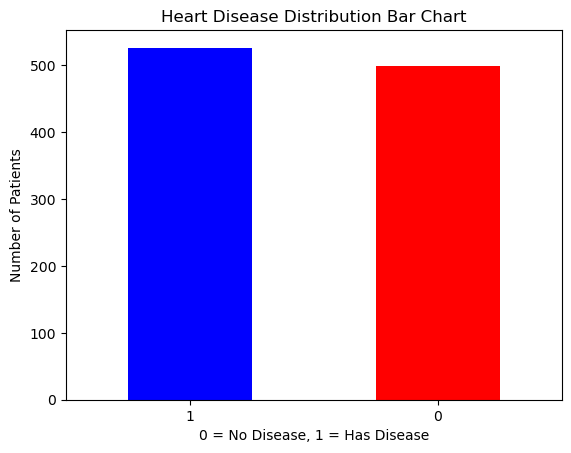

In [9]:
df['target'].value_counts().plot(kind='bar', color=['blue', 'red'])
plt.title("Heart Disease Distribution Bar Chart")
plt.xlabel("0 = No Disease, 1 = Has Disease")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.show()

In [20]:
X = df.drop('target', axis=1)  # all the columns except target
y = df['target']               # only the target column

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("Feature columns:", X.columns.tolist())

Features shape: (1025, 13)
Target shape: (1025,)
Feature columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [26]:
# Scaling puts everything on the same level
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Before scaling the age mean is:", X['age'].mean().round(2))
print("After scaling the age mean is:", X_scaled[:, 0].mean().round(2))

Before scaling the age mean is: 54.43
After scaling the age mean is: -0.0


In [30]:
# Split 1: 80% train and 20% test
X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

# Split 2: 70% train and 30% test
X_train_70, X_test_70, y_train_70, y_test_70 = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42)

# Split 3: 75% train and 25% test
X_train_75, X_test_75, y_train_75, y_test_75 = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42)

print("Split 80/20 Train:", X_train_80.shape, "Test:", X_test_80.shape)
print("Split 70/30 Train:", X_train_70.shape, "Test:", X_test_70.shape)
print("Split 75/25 Train:", X_train_75.shape, "Test:", X_test_75.shape)

Split 80/20 Train: (820, 13) Test: (205, 13)
Split 70/30 Train: (717, 13) Test: (308, 13)
Split 75/25 Train: (768, 13) Test: (257, 13)


In [36]:
#Model 1: Logistic Regression
model_1 = LogisticRegression(random_state=42)

# Test on 80/20 split
model_1.fit(X_train_80, y_train_80)
pred_80 = model_1.predict(X_test_80)
acc_80 = accuracy_score(y_test_80, pred_80)

# Test on 70/30 split
model_1.fit(X_train_70, y_train_70)
pred_70 = model_1.predict(X_test_70)
acc_70 = accuracy_score(y_test_70, pred_70)

# Test on 75/25 split
model_1.fit(X_train_75, y_train_75)
pred_75 = model_1.predict(X_test_75)
acc_75 = accuracy_score(y_test_75, pred_75)

print("Model 1:Logistic Regression Results:")
print(f"80/20 split accuracy: {acc_80:.4f}")
print(f"70/30 split accuracy: {acc_70:.4f}")
print(f"75/25 split accuracy: {acc_75:.4f}")

Model 1:Logistic Regression Results:
80/20 split accuracy: 0.7951
70/30 split accuracy: 0.8052
75/25 split accuracy: 0.7899


In [40]:
#Classification Report
# Using the 70/30 since it performed the best
model_1.fit(X_train_70, y_train_70)
pred_70 = model_1.predict(X_test_70)

print("Detailed Classification Report (70/30 split):")
print(classification_report(y_test_70, pred_70,
      target_names=['No Disease', 'Has Disease']))

Detailed Classification Report (70/30 split):
              precision    recall  f1-score   support

  No Disease       0.86      0.75      0.80       159
 Has Disease       0.76      0.87      0.81       149

    accuracy                           0.81       308
   macro avg       0.81      0.81      0.80       308
weighted avg       0.81      0.81      0.80       308



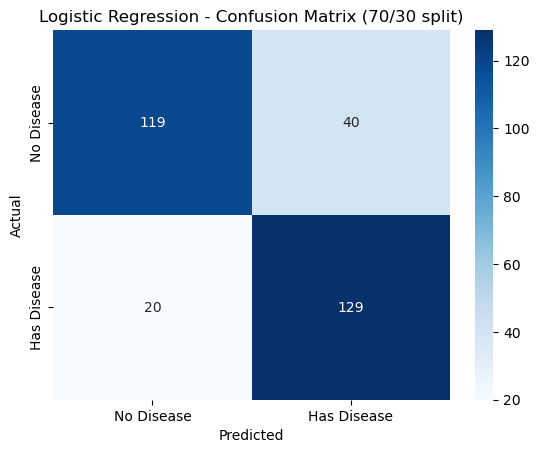

In [44]:
cm = confusion_matrix(y_test_70, pred_70)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Has Disease'],
            yticklabels=['No Disease', 'Has Disease'])
plt.title('Logistic Regression - Confusion Matrix (70/30 split)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()